In [1]:
import os 
import sys
sys.path.append("../../")


import numpy as np
import torch
import torch.nn as nn

from vi_rnn.vae import VAE
from vi_rnn.train import train_VAE
from torch.utils.data import DataLoader
from vi_rnn.datasets import Reaching, Reaching_Teacher
from vi_rnn.mock_nm_dataset import * 
from py_rnn.model import RNN, predict
from py_rnn.train import train_rnn
from py_rnn.train import save_rnn, load_rnn
from vi_rnn.utils import *
import matplotlib.pyplot as plt
from vi_rnn.saving import save_model, load_model
from vi_rnn.evaluation import * 
from py_rnn.default_params import get_default_params

%matplotlib inline

In [2]:
data_dir = '../../data/mante_rank_2_postsynaptic/'
model_dir = '../../models/students/'
figures_dir = '../../figures'
cuda = False  # toggle if GPU is available
device = 'cpu'
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
os.environ['TORCH_USE_CUDA_DSA'] = '1'
neuromodulation = 'postsynaptic' # one of 'presynaptic', 'postsynaptic', 'additive', None
train_nm_params = False
train_batches = 4

### Load dataset

In [3]:
x = np.load(''.join([data_dir, 'x_fr.npy'])) # population firing rates
# y = np.load(''.join([data_dir, 'y.npy'])) # Teacher output

# task_label = np.load(''.join([data_dir, 'output_arr.npy']))

s = np.load(''.join([data_dir, 'z_fr.npy'])) # neuromodulator states 

task_input = np.load(''.join([data_dir, 'input_arr.npy'])) # MWG task input 

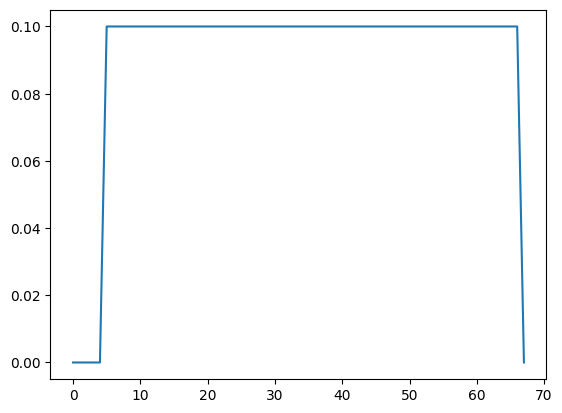

In [4]:
plt.plot(s[0, :, 1])

In [5]:
x = torch.from_numpy(x).to(device).to(torch.float32)
# x = x.permute(1, 2, 0)
x = x[:100]
# y = torch.from_numpy(y).to(device).to(torch.float32)
s = torch.from_numpy(s).to(device).to(torch.float32)
task_input = torch.from_numpy(task_input).to(device).to(torch.float32) 

# task_label = torch.from_numpy(task_label).to(device).to(torch.float32)
task_input = task_input[:100]
s = s[:100]

In [17]:
# Initialise VI / student setup

dim_z = 2
dim_N = x.size(2)
dim_x = x.size(2)
dim_u = task_input.size(2)
dim_s = 2

bs = 4
n_epochs = 20000
wandb = False
# initialise encoder
enc_params = {"obs_grad": True, "init_scale": 0.1}

task_params = {
    "dur": x.size(1),
    "n_trials": x.size(0),
    "out": "currents",
    "n_neurons": dim_x,
    "non_lin": nn.ReLU(),
    "name": "mante_postsynaptic"
}

# initialise prior
prior_params = {
    "train_noise_x": False,
    "train_noise_z": False,
    "train_noise_z_t0": False,
    "init_noise_z": 0.05,
    "init_noise_z_t0": 1,
    "init_noise_x": 0.1,
    "scalar_noise_z": "Cov",
    "scalar_noise_x": False,
    "scalar_noise_z_t0": "Cov",
    "identity_readout": True,
    "activation": "relu",
    "exp_par": True,
    "shared_tau": 0.4,
    "readout_rates": task_params['out'],
    "train_obs_bias": False,
    "train_obs_weights": False,
    "train_latent_bias": False,
    "train_neuron_bias": True,
    "orth": False,
    "m_norm": False,
    "weight_dist": "uniform",
    "weight_scaler": 1,  # /dim_N,
    "initial_state": "trainable",
    "out_nonlinearity": "identity",
    "neuromodulation": neuromodulation,
    "train_nm_params": train_nm_params
}

training_params = {
    "lr": 0.0001,
    "step_size": 400, 
    "gamma": 0.91,
    "lr_end": 1e-7,
    "opt_eps": 1e-8,
    "n_epochs": n_epochs,
    "grad_norm": 0,
    "bootstrap": False,
    "eval_epochs": 10,
    "batch_size": x.size(0),
    "cuda": cuda,
    "smoothing": 20,
    "freq_cut_off": 10000,
    "sim_obs_noise": 0,
    "sim_latent_noise": 1,
    "k": 64, 
    "loss_f": "opt_VGTF",
    "resample": "systematic",  # , multinomial or none"
    "run_eval": False,
    "smooth_at_eval": False,
    "neuromodulation": neuromodulation,
    "sim_v": True
}

# initialise encoder
enc_params = {
    **enc_params,
    "init_kernel_sizes": [21, 11, 1],
    "nonlinearity": "gelu",
    "n_channels": [64, 64],
    "init_scale": 0.1,
    "constant_var": False,
    "n_hidden": 64,
    "strides": [1, 1, 1],
    "dilations": [1, 1, 1],
    "padding": "same",
    "padding_mode": "circular",
}

VAE_params = {
    "dim_x": dim_x,
    "dim_z": dim_z,
    "dim_u": dim_u,
    "dim_N": dim_N,
    "dim_s": dim_s,
    "enc_architecture": "Inv_Obs",
    "enc_params": enc_params,
    "prior_architecture": "PLRNN",
    "prior_params": prior_params,
    "causal": True,
}


In [7]:
# x_train = x_train.permute(2, 1, 0)
training_task = MockDataset(task_params, x, task_input, s=s)
# eval_task = MockDataset(task_params, x, task_input_test, s_test)
vae = VAE(VAE_params)

Neuromodulation type: postsynaptic
using ReLU activation
using uniform init
weight scaler 1


In [9]:
train_VAE(
    vae,
    training_params,
    training_task,
    eval_task=None,
    sync_wandb=wandb,
    out_dir=model_dir,
    fname=None,
    store_train_stats=False,
)

Training on : cpu
Learning rate decay factor 0.9961697125149411
epoch 1 loss: -40.5266, ll: 40.5266, ll_x: -42.6875, ll_z: -3.1924 H: 5.2711, alpha: 0.37, lr: 0.010000, N_z: 0.0500, N_x: 0.1000
epoch 2 loss: -40.5557, ll: 40.5557, ll_x: -42.7160, ll_z: -3.1913 H: 5.2711, alpha: 0.37, lr: 0.010000, N_z: 0.0500, N_x: 0.1000
epoch 3 loss: -40.5828, ll: 40.5828, ll_x: -42.7453, ll_z: -3.1922 H: 5.2722, alpha: 0.37, lr: 0.010000, N_z: 0.0500, N_x: 0.1000
epoch 4 loss: -40.6111, ll: 40.6111, ll_x: -42.7720, ll_z: -3.1934 H: 5.2717, alpha: 0.37, lr: 0.010000, N_z: 0.0500, N_x: 0.1000
epoch 5 loss: -40.6400, ll: 40.6400, ll_x: -42.7982, ll_z: -3.1918 H: 5.2689, alpha: 0.37, lr: 0.010000, N_z: 0.0500, N_x: 0.1000
epoch 6 loss: -40.6675, ll: 40.6675, ll_x: -42.8278, ll_z: -3.1908 H: 5.2708, alpha: 0.37, lr: 0.010000, N_z: 0.0500, N_x: 0.1000
epoch 7 loss: -40.6697, ll: 40.6697, ll_x: -42.8297, ll_z: -3.1914 H: 5.2695, alpha: 0.37, lr: 0.010000, N_z: 0.0500, N_x: 0.1000
epoch 8 loss: -40.6761, ll

[]

In [8]:
# load model 
model, vae_params, task_params, training_params = load_model(name=model_dir + "/../../models/students/mante_postsynaptic_Inv_Obs_LRRNN_Z_Date_22024_10_30_T_16_53_20")

dict_keys(['dim_x', 'dim_z', 'dim_u', 'dim_N', 'dim_s', 'enc_architecture', 'enc_params', 'causal', 'rnn_params', 'rnn_architecture'])
Neuromodulation type: postsynaptic
using ReLU activation
using uniform init
weight scaler 1


c:\Users\kaleab.belay\Documents\Project\mnm\train_scripts\student_teacher\../..\vi_rnn\saving.py:125: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  d = torch.load(state_dict

In [9]:
model.rnn.d_s = None

### Get predictions for each trial/batch

In [10]:
X_pred = torch.zeros_like(x)
model = vae
model.eval()
for b in range(x.shape[0]):
    X_pred[b] = predict_X(
        model, 
        x.size(1),
        x[b].T,
        task_input[b].T.unsqueeze(0),
        s[b].T.unsqueeze(0),
        # s=None
    ).reshape(dim_x, -1).T
    

torch.Size([1, 2, 68, 1])
z0 shape: torch.Size([2])
torch.Size([1, 2, 68, 1])
z0 shape: torch.Size([2])
torch.Size([1, 2, 68, 1])
z0 shape: torch.Size([2])
torch.Size([1, 2, 68, 1])
z0 shape: torch.Size([2])
torch.Size([1, 2, 68, 1])
z0 shape: torch.Size([2])
torch.Size([1, 2, 68, 1])
z0 shape: torch.Size([2])
torch.Size([1, 2, 68, 1])
z0 shape: torch.Size([2])
torch.Size([1, 2, 68, 1])
z0 shape: torch.Size([2])
torch.Size([1, 2, 68, 1])
z0 shape: torch.Size([2])
torch.Size([1, 2, 68, 1])
z0 shape: torch.Size([2])
torch.Size([1, 2, 68, 1])
z0 shape: torch.Size([2])
torch.Size([1, 2, 68, 1])
z0 shape: torch.Size([2])
torch.Size([1, 2, 68, 1])
z0 shape: torch.Size([2])
torch.Size([1, 2, 68, 1])
z0 shape: torch.Size([2])
torch.Size([1, 2, 68, 1])
z0 shape: torch.Size([2])
torch.Size([1, 2, 68, 1])
z0 shape: torch.Size([2])
torch.Size([1, 2, 68, 1])
z0 shape: torch.Size([2])
torch.Size([1, 2, 68, 1])
z0 shape: torch.Size([2])
torch.Size([1, 2, 68, 1])
z0 shape: torch.Size([2])
torch.Size([

#### Plot student neural activity vs teacher activity

c:\Users\kaleab.belay\Documents\Project\mnm\train_scripts\student_teacher\../..\vi_rnn\evaluation.py:127: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\TensorShape.cpp:3701.)
  pred_trajectories_ = pred_trajectories.T.reshape(n_trials*trial_dur, -1)


n outliers: 0.009000000000000008


C:\Users\kaleab.belay\AppData\Local\Temp\ipykernel_19824\1706149701.py:17: UserWarning: You have mixed positional and keyword arguments, some input may be discarded.
  fig.legend([idx_i, idx_j], labels=['Neural activity', 'Predicted Neural activity'], loc='upper right')


n outliers: 0.0
n outliers: 0.0
n outliers: 0.07099999999999995
n outliers: 0.0
n outliers: 0.0
n outliers: 0.0
n outliers: 0.0
n outliers: 0.21199999999999997
n outliers: 0.0


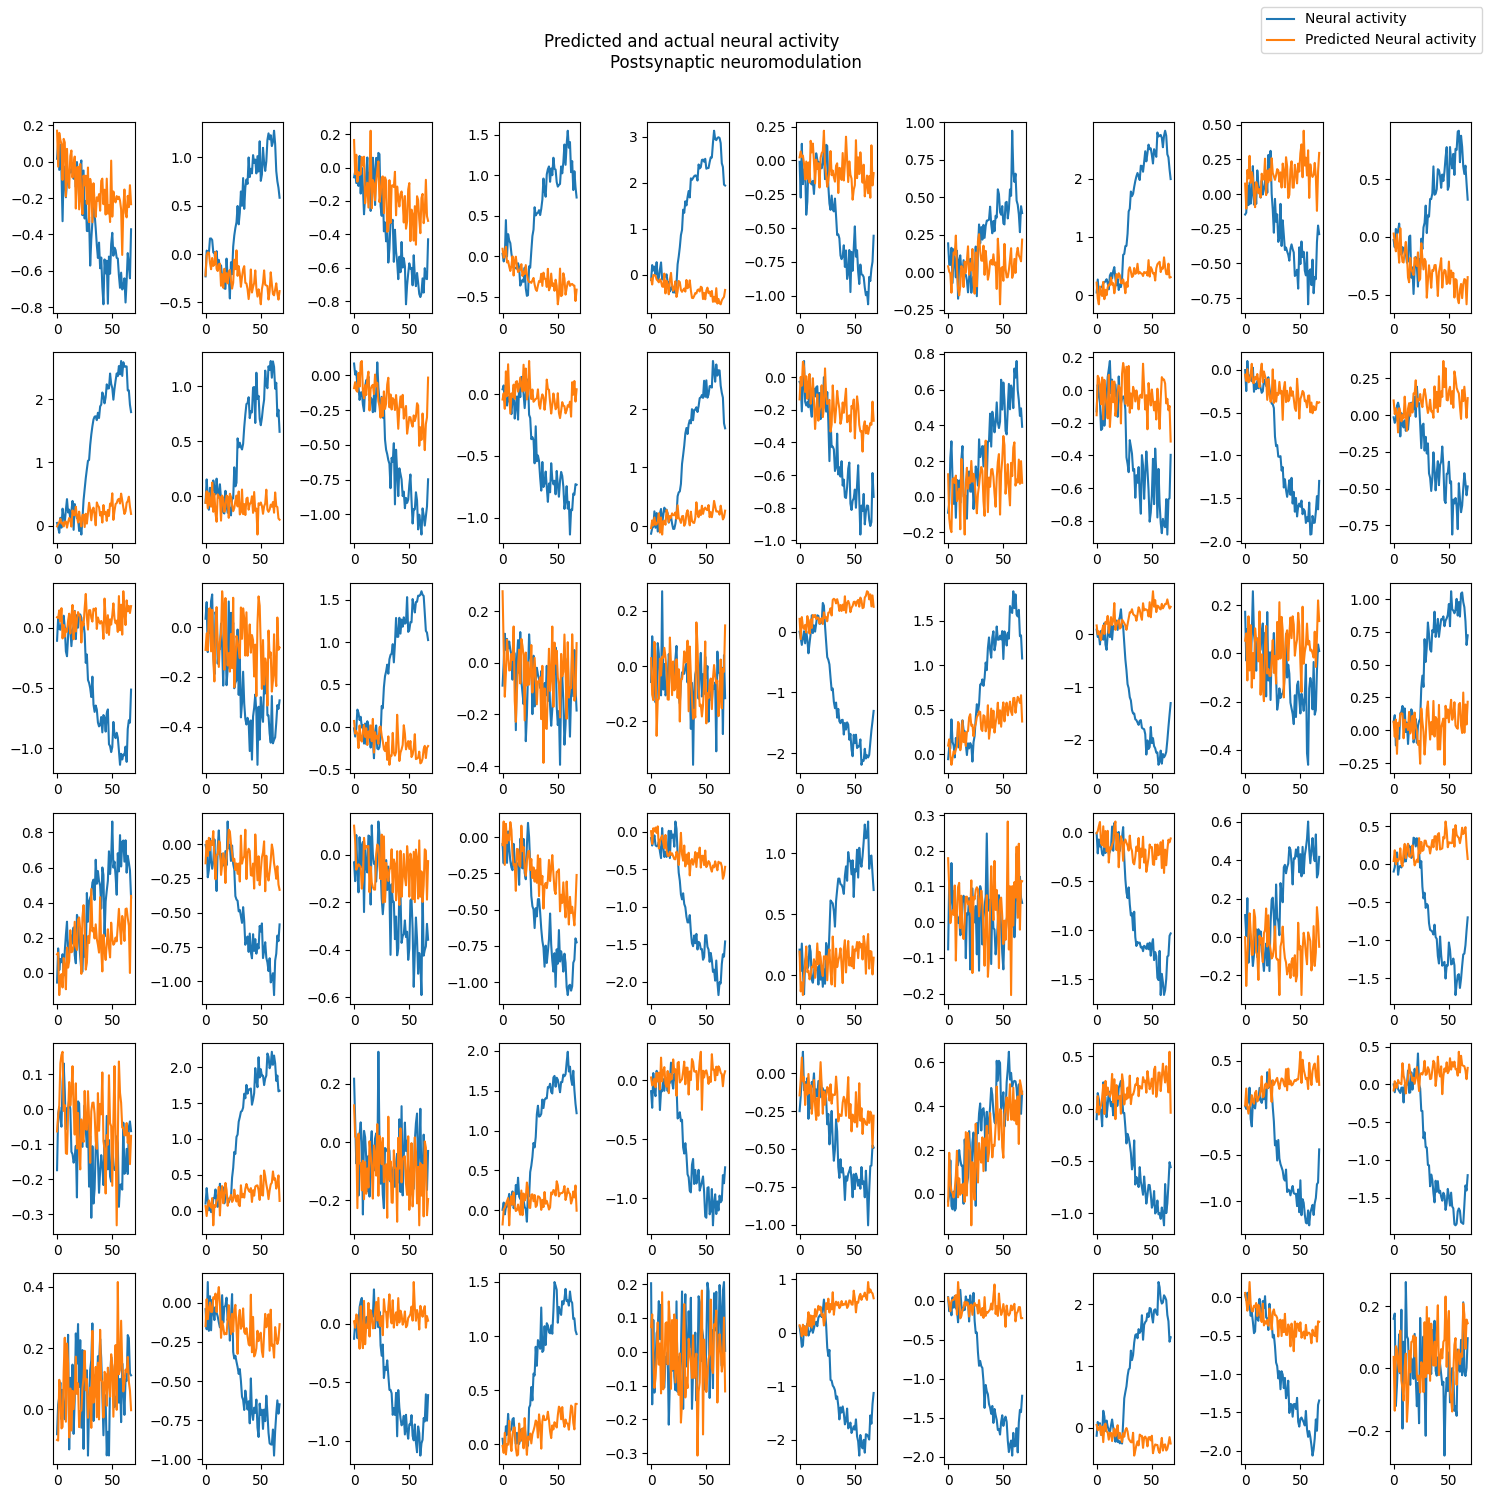

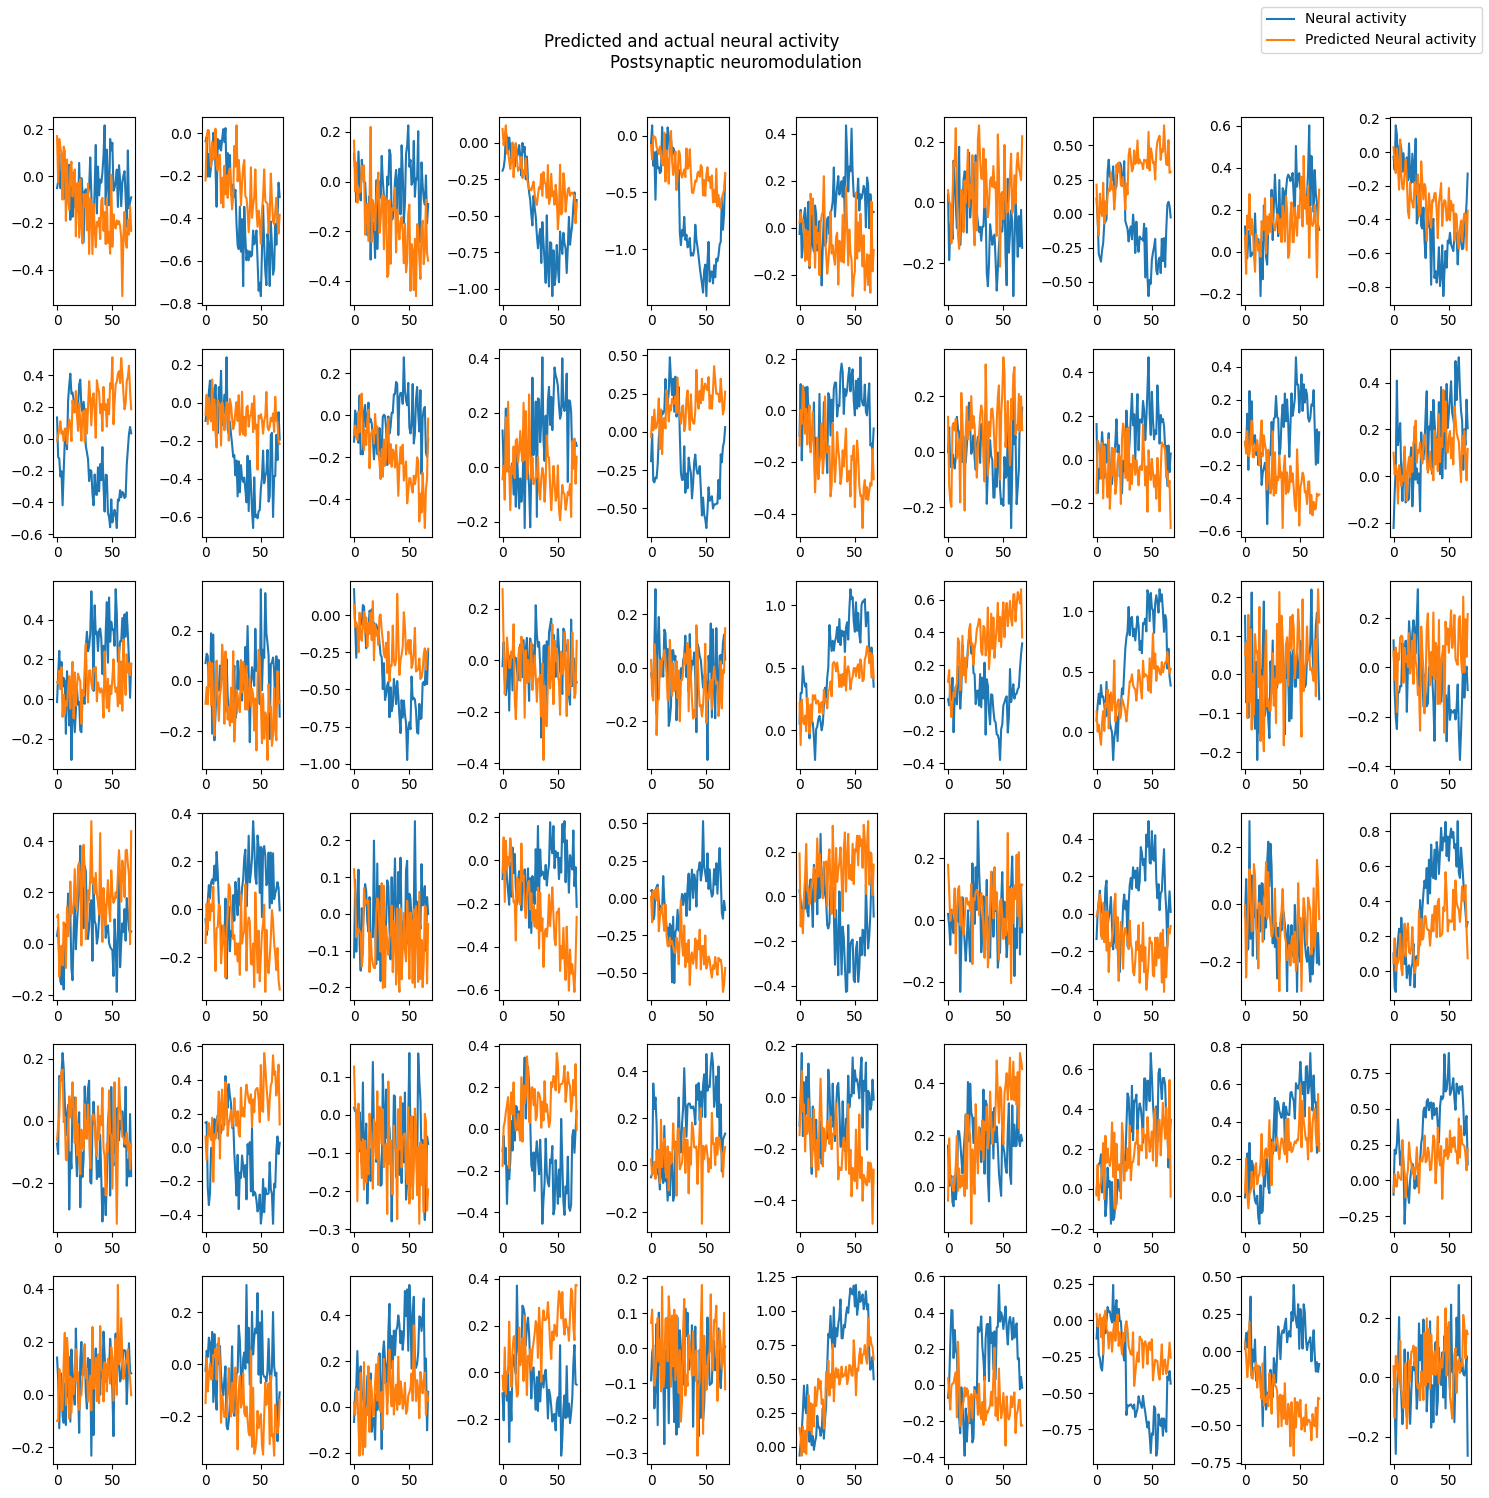

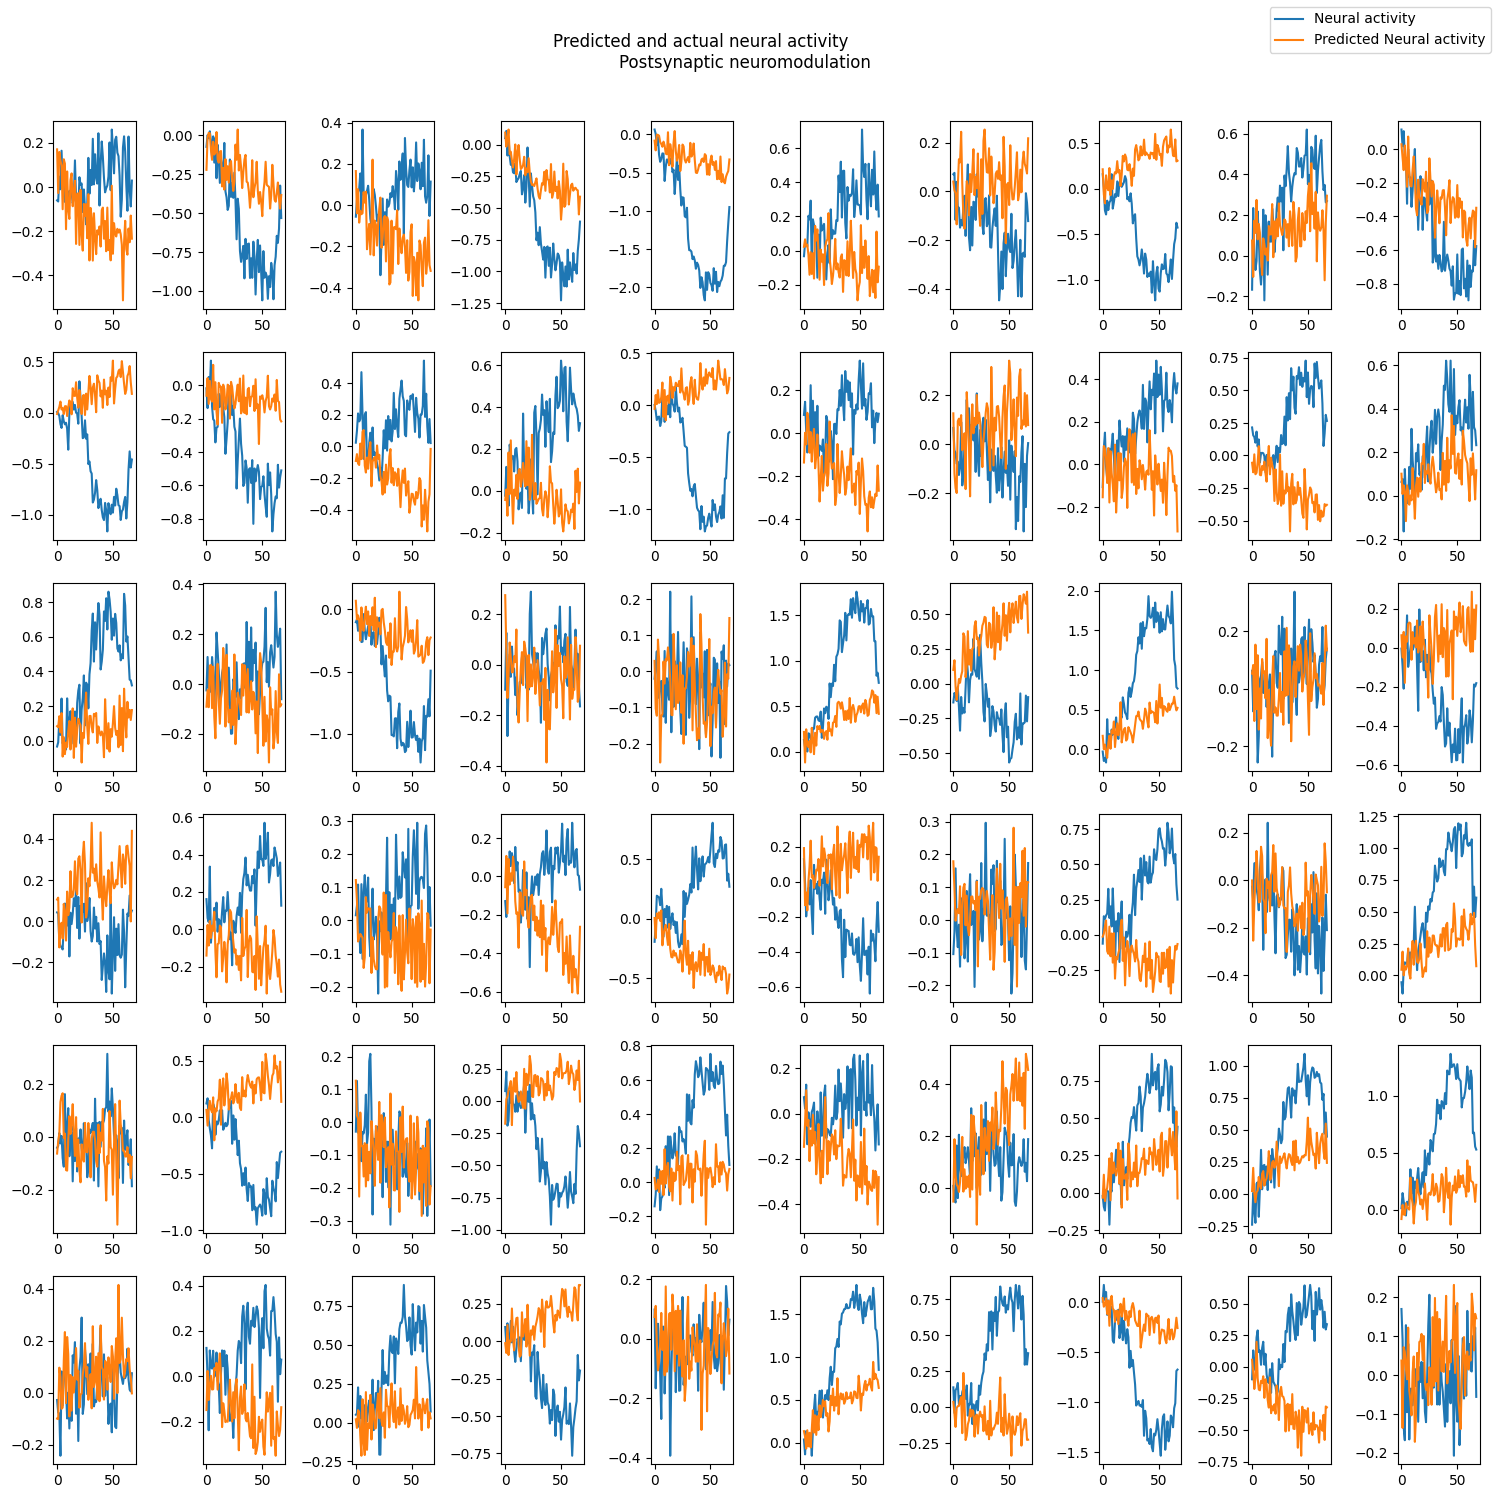

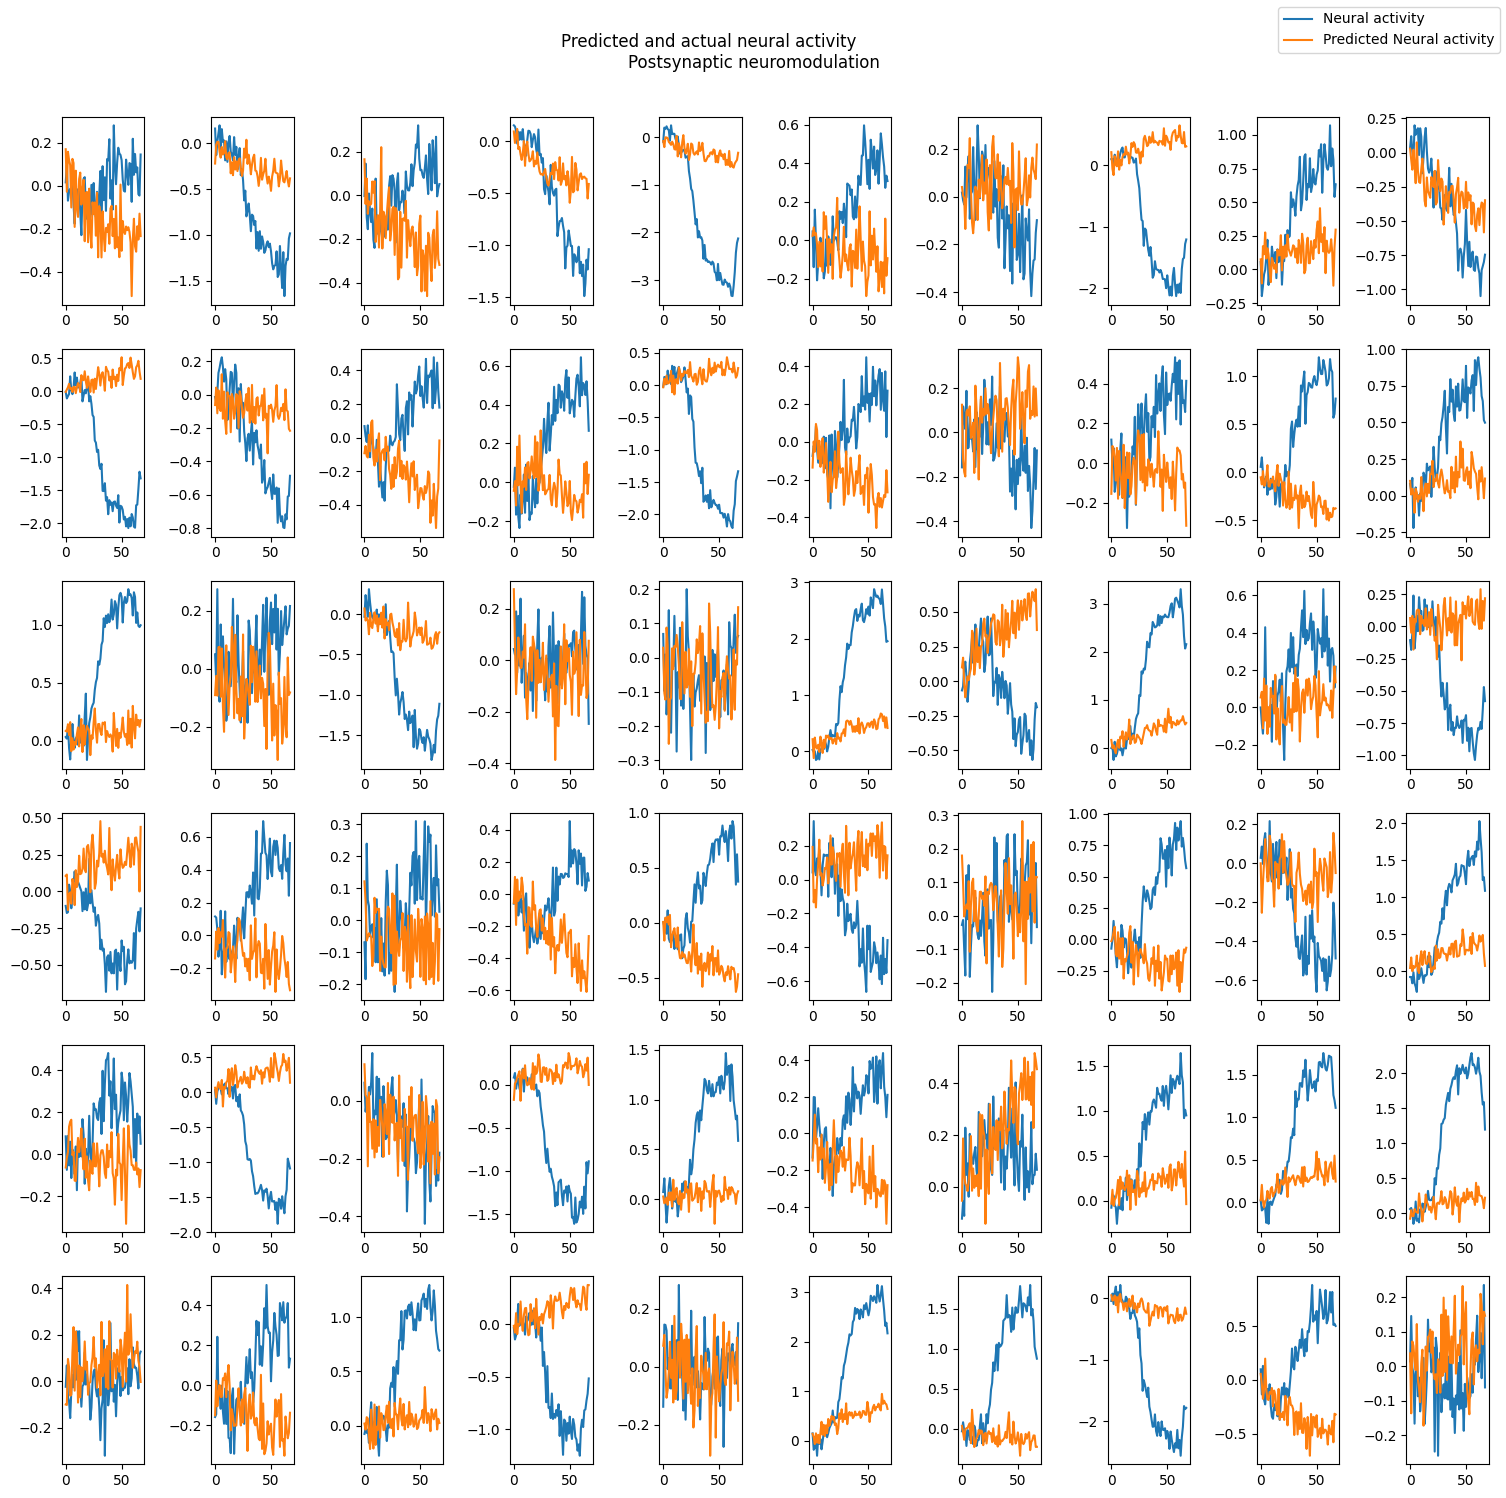

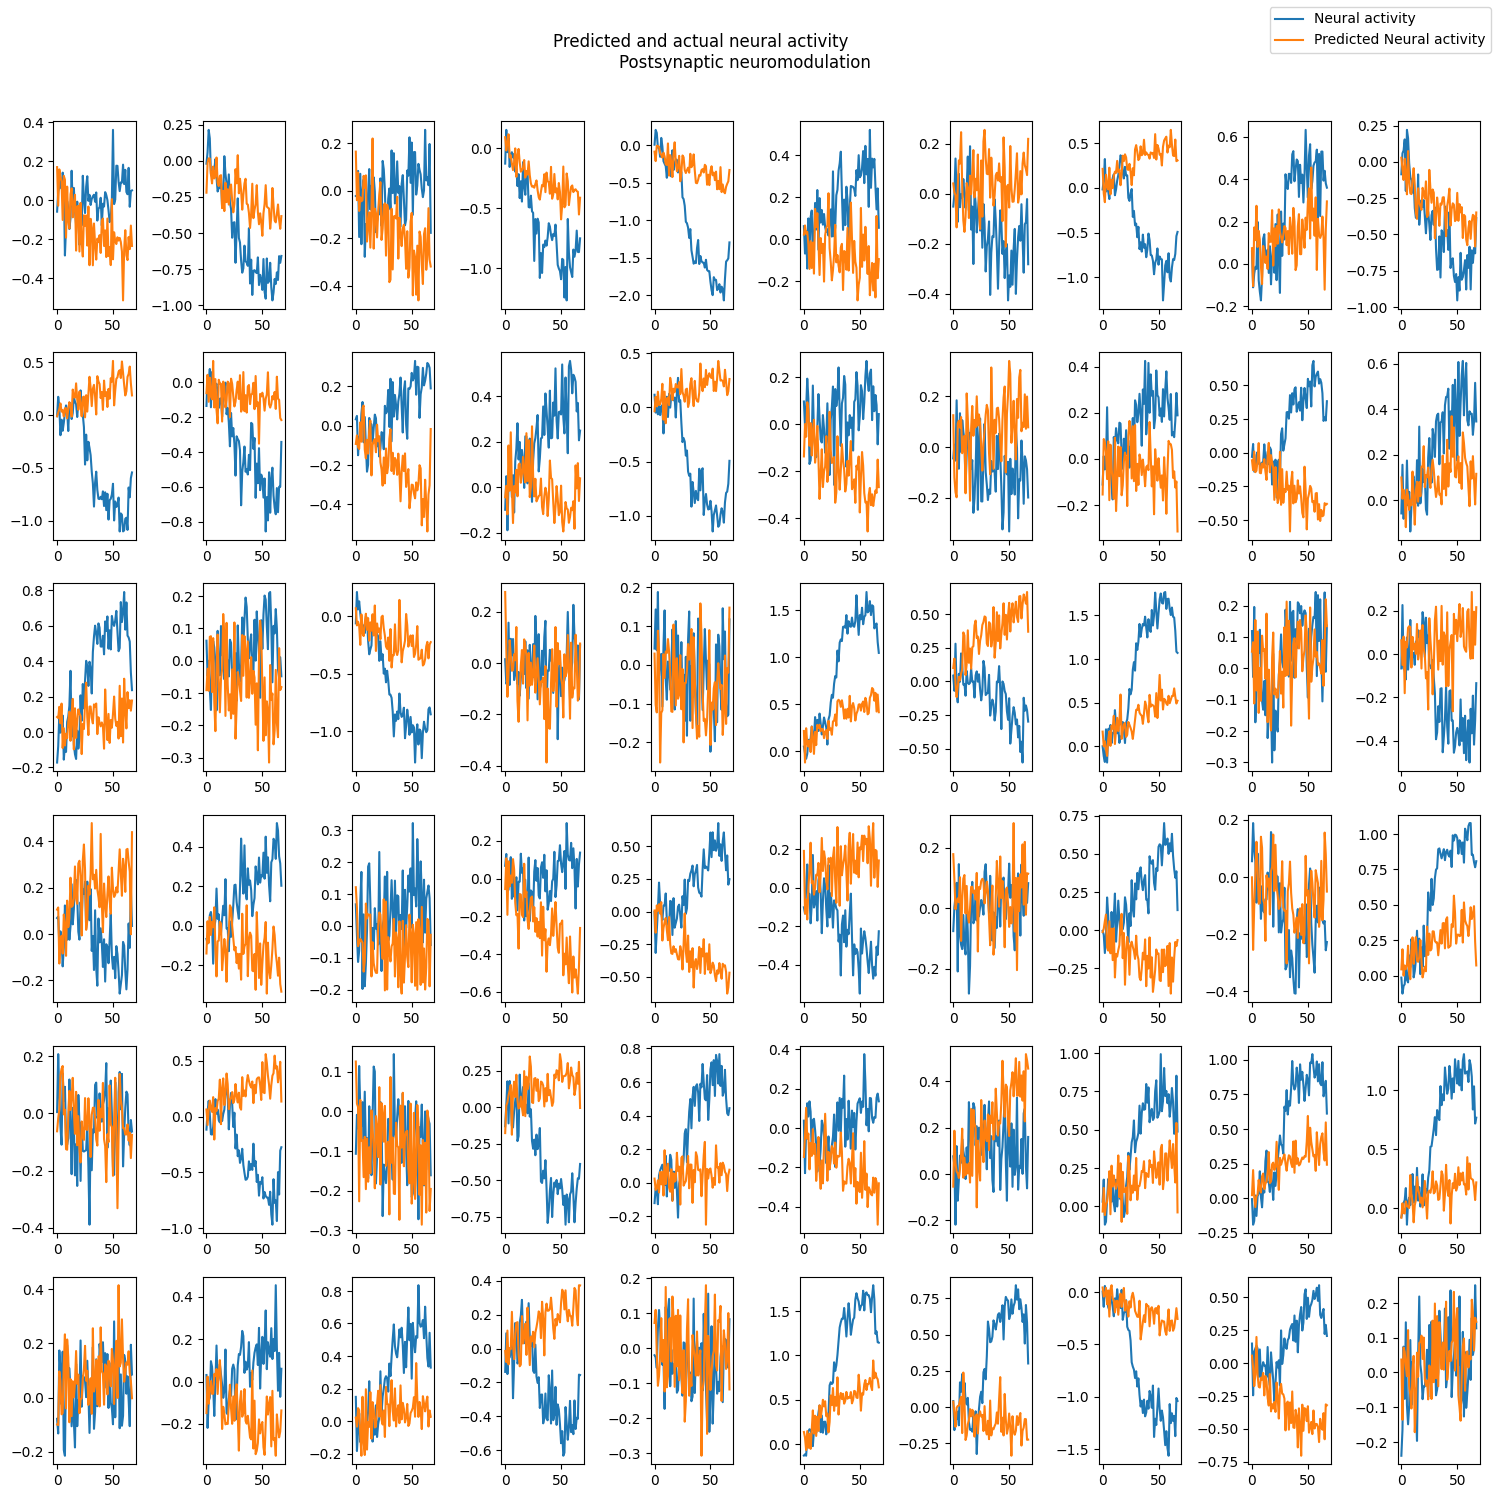

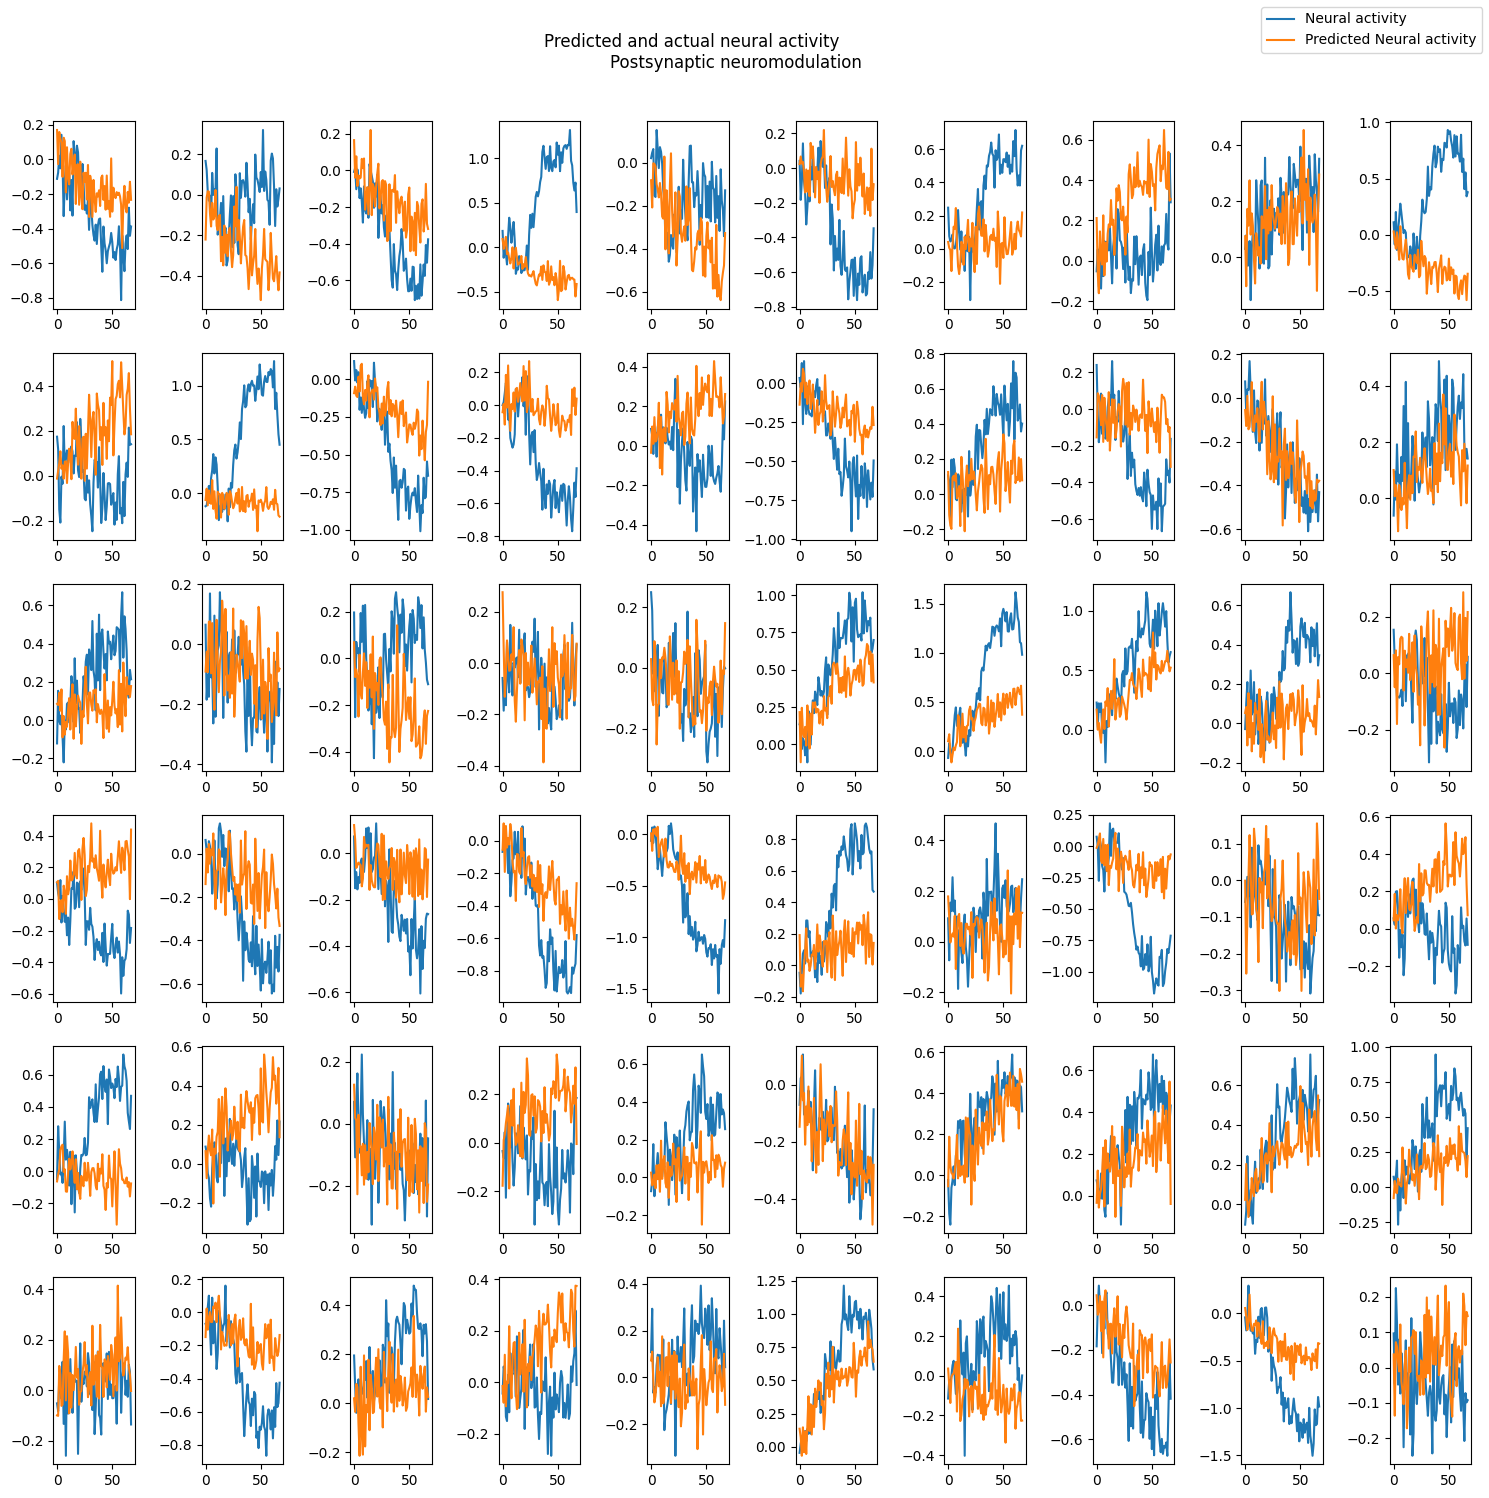

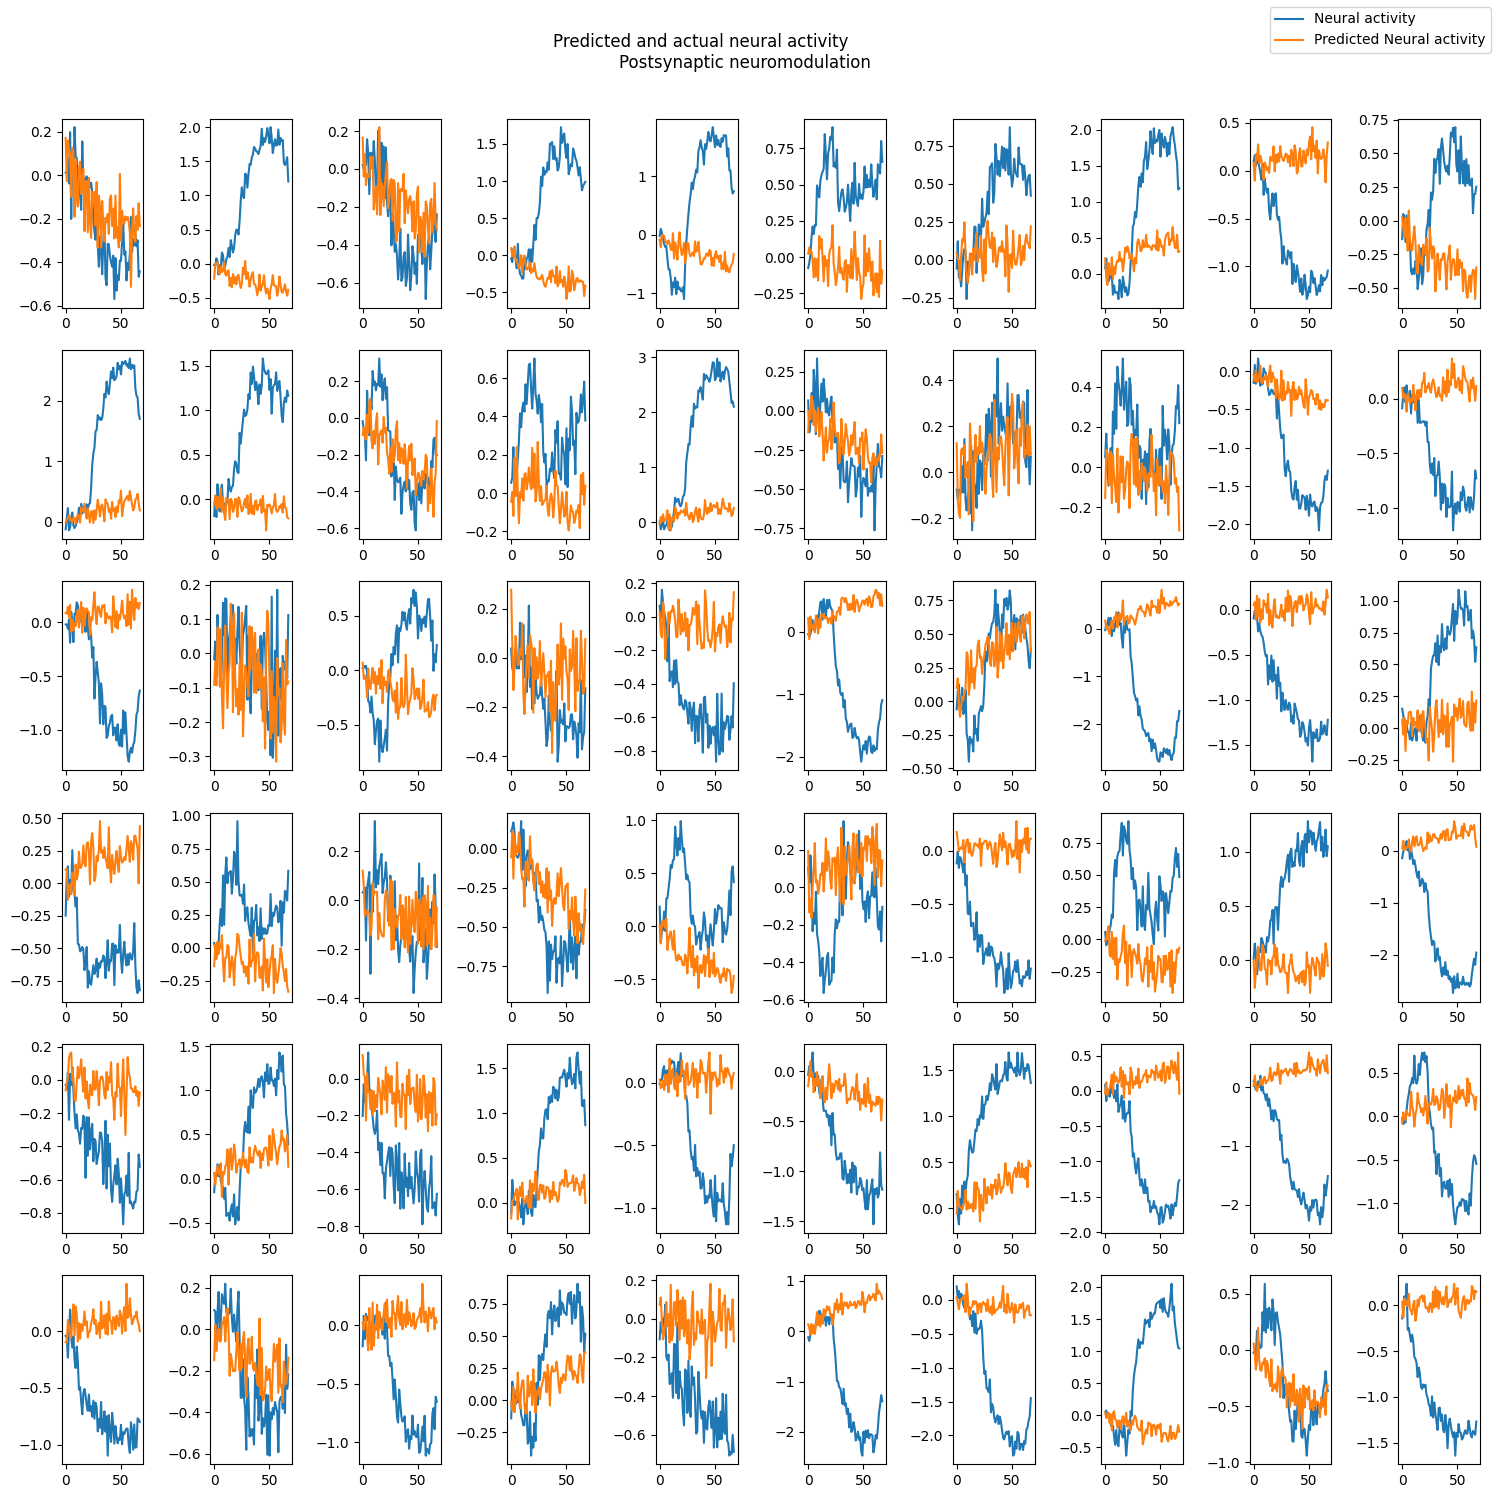

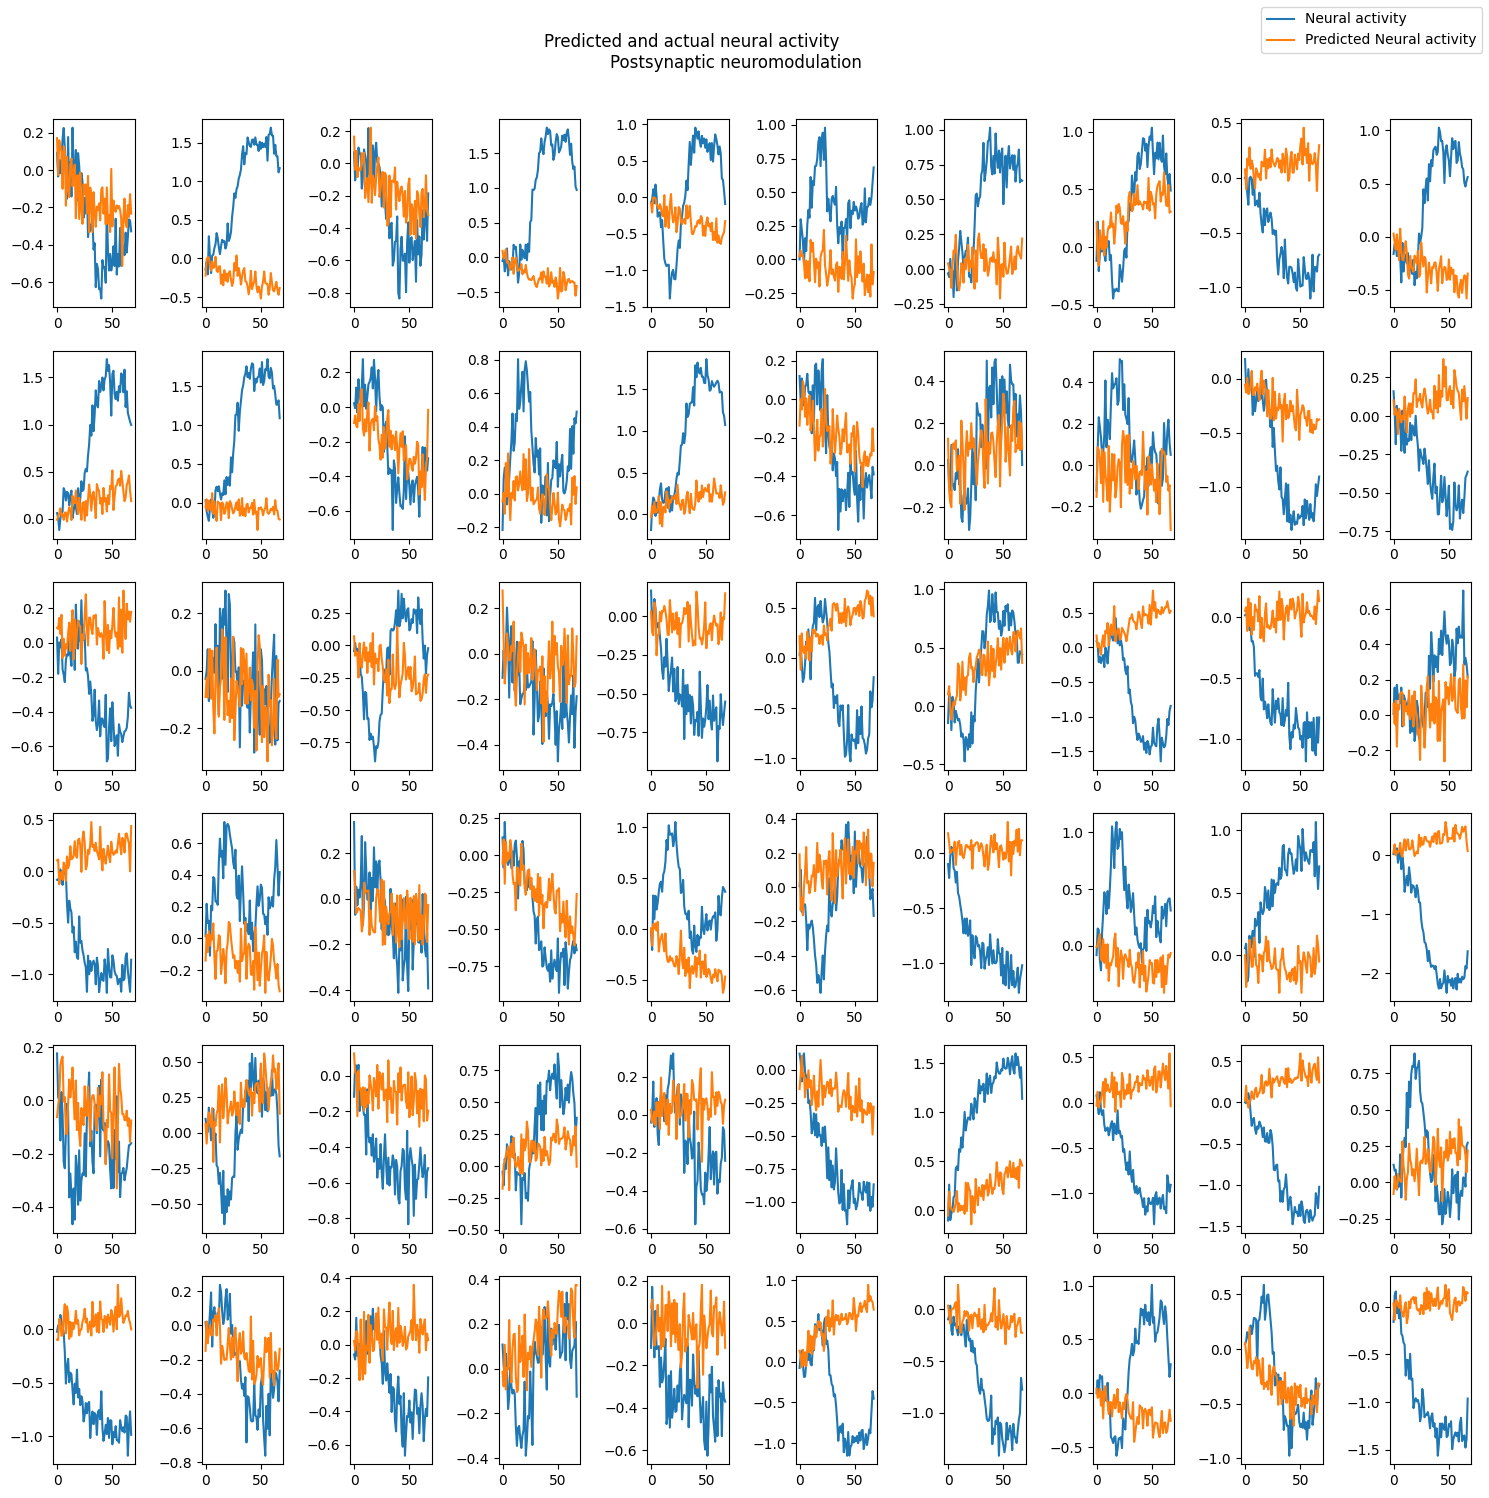

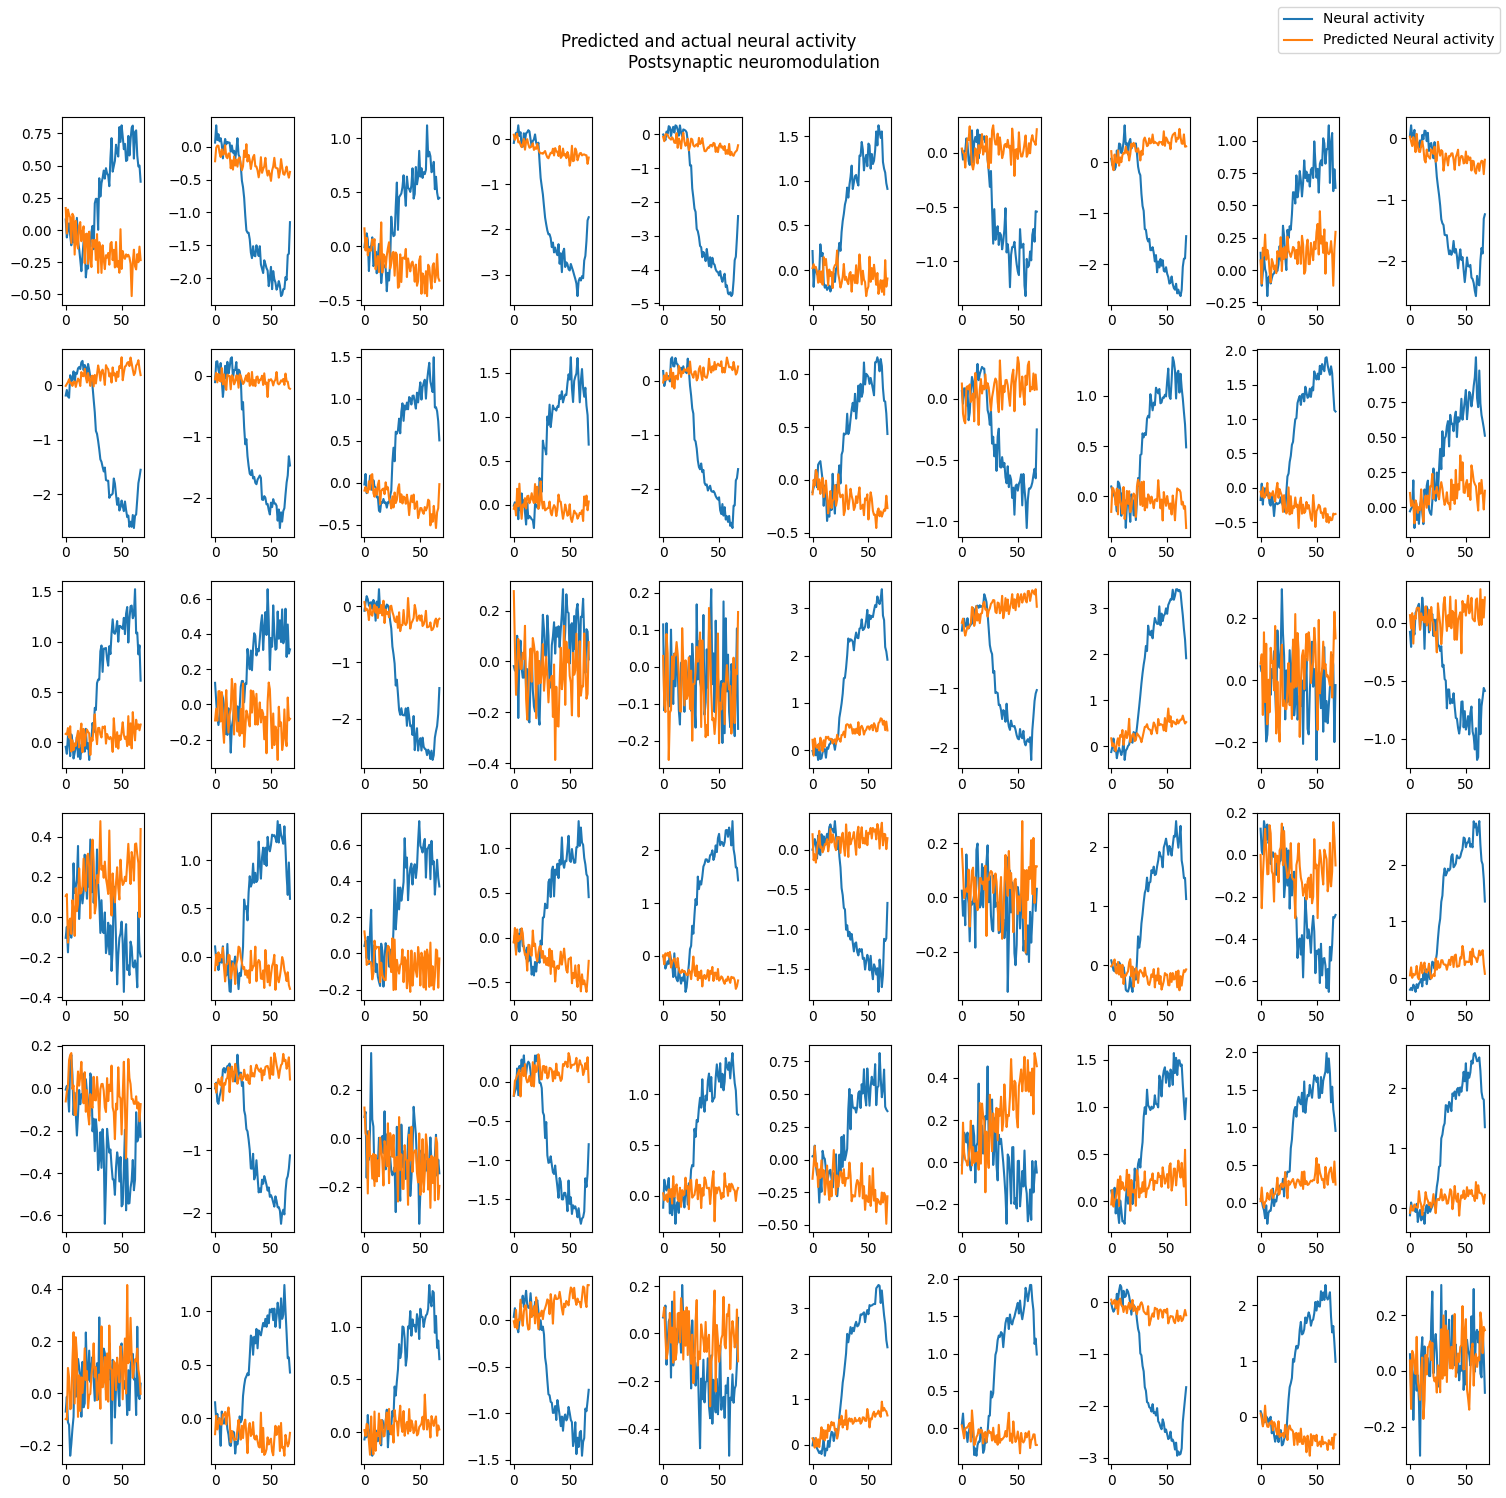

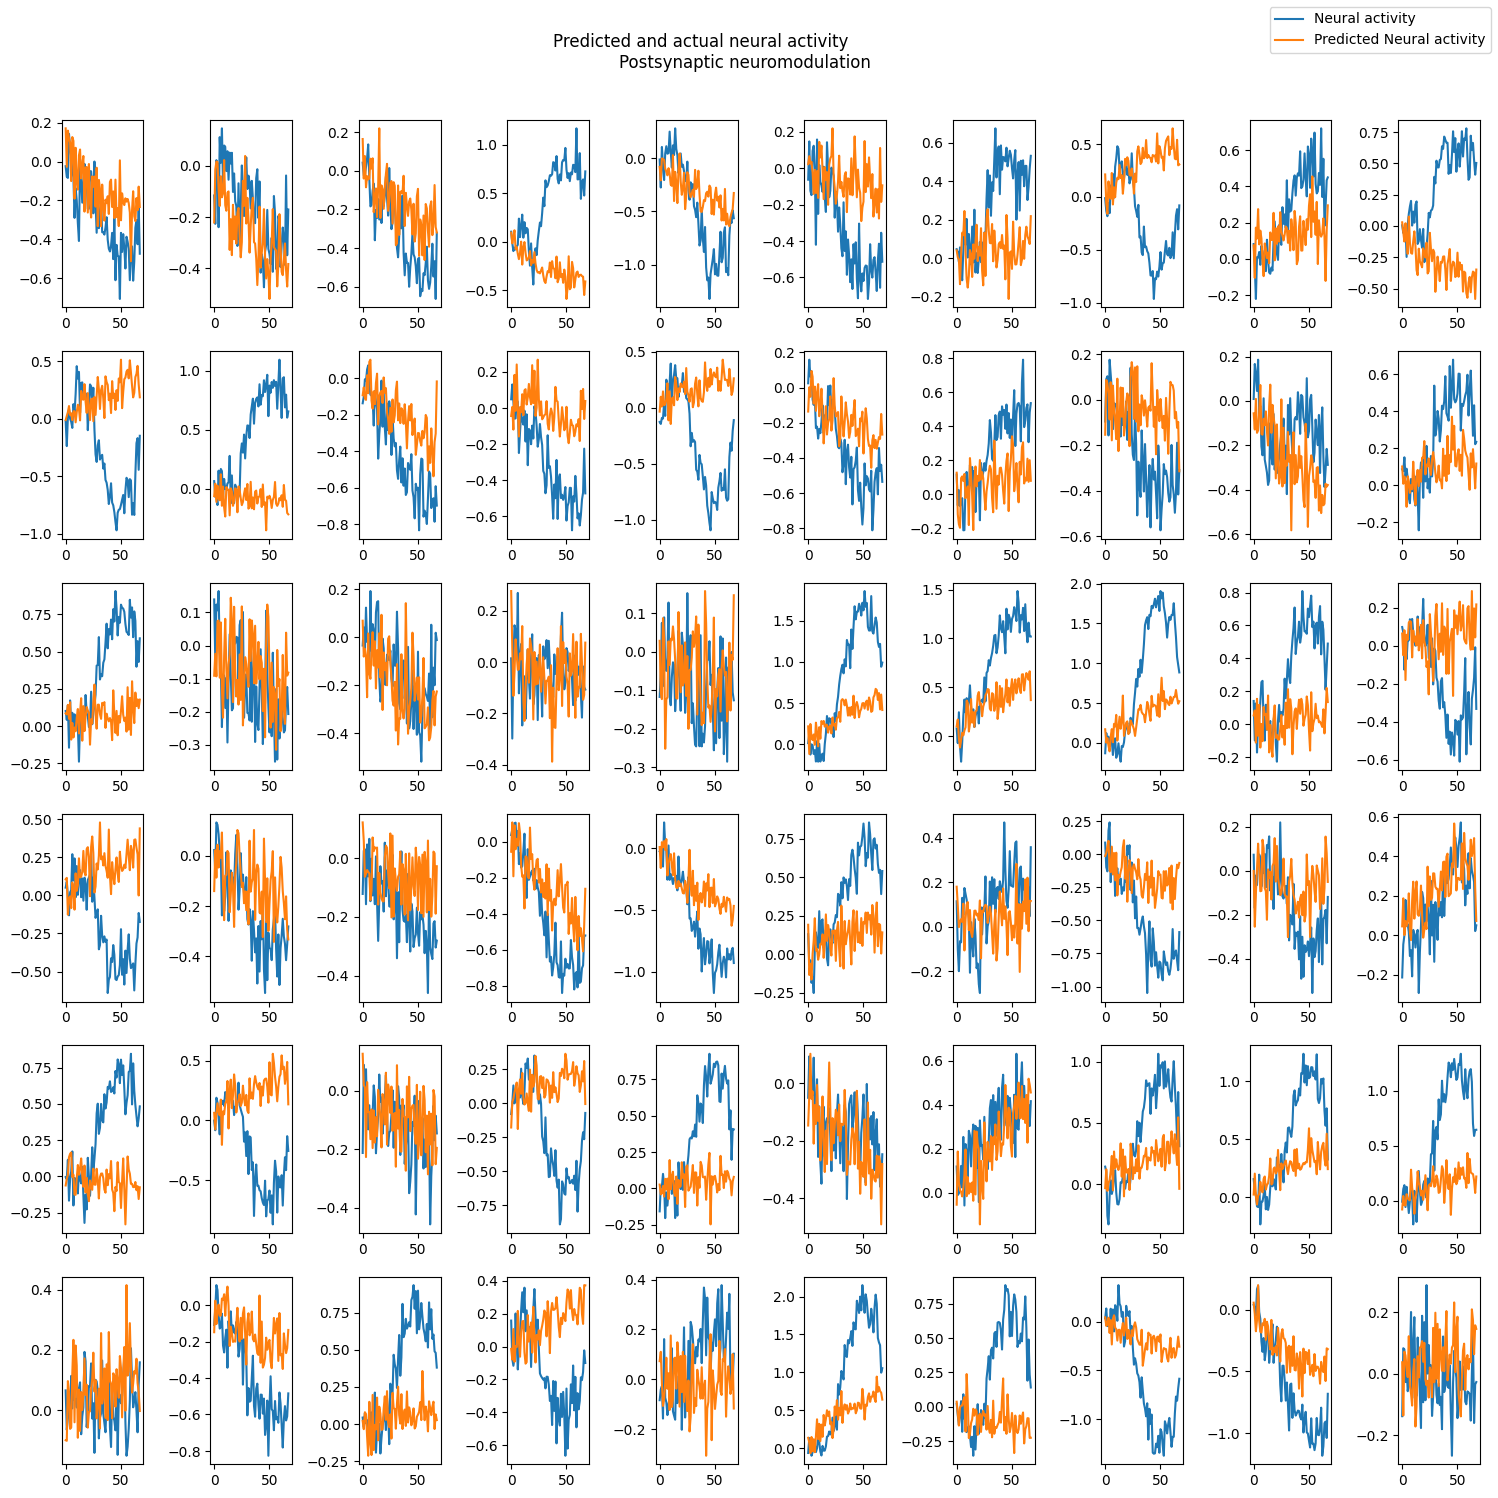

In [11]:
import matplotlib.pyplot as plt 
kl_div = []
for b in range(10):
    # compute the KL-Divergence 
    kl_div_b = compute_KL_divergence(X_pred[b].unsqueeze(0), x[b])
    kl_div.append(kl_div_b) 
    # plot population activity 
    fig, ax = plt.subplots(6, 10, figsize=(15, 15))
    idx_i, idx_j = 0, 0
    for i in range(task_params["n_neurons"]):
        ax[idx_i, idx_j].plot(x[b, :, i], label=f'Neural activity')
        ax[idx_i, idx_j].plot(X_pred[0, :, i], label=f'Predicted Neural activity')
        idx_j += 1
        if idx_j >= 10: 
            idx_i, idx_j = idx_i + 1, 0
        
    fig.legend([idx_i, idx_j], labels=['Neural activity', 'Predicted Neural activity'], loc='upper right')
    fig.suptitle(f"Predicted and actual neural activity\
                 \nPostsynaptic neuromodulation")
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    fig.savefig(f"{figures_dir}/reaching_unmodulated_{b}.png")
    # plt.show()
    
    

In [12]:
np.array(kl_div).mean()

5.475722813606263

#### Compute $\mathbf{R}^2$ for each neuron across trials

In [ ]:
# what do the individual neuron responses look like? 
for neur_idx in range(task_params["n_neurons"]):
# neur_idx = 3
    fig, ax = plt.subplots(7, 1, figsize=(10, 10))
    for idx, b in enumerate(range(0, x_test.shape[0], 2)):
        ax[idx].plot(x_test[b, :, neur_idx], label=f'MWG Duration: {b * 2 + 24}')
        ax[idx].axvline(torch.where(task_input_test[b, :, 0] == 10.0)[0], c='g', linestyle='--')
        ax[idx].axvline(torch.where(task_input_test[b, :, 1] == 10.0)[0], c='y', linestyle='--')
        ax[idx].axvline(torch.where(task_input_test[b, :, 2] == 10.0)[0], c='r', linestyle='--')
        ax[idx].legend()
    plt.tight_layout()
    fig.savefig(f"{figures_dir}/sn_activity_{neur_idx}.png")
        # break
    

In [14]:
import seaborn as sns
from scipy.stats import pearsonr
# compute pearson's r

pearson_r = np.zeros((task_params["n_neurons"], x.size(0)))
for i in range(task_params["n_neurons"]):
    for b in range(x.shape[0]):
        pearson_r[i][b] = pearsonr(x[b, :, i], X_pred[b, :, i])[0]

In [16]:
pearson_r.mean()

0.2013967819570455

Text(0.5, 1.0, 'Pearson $R$ heatmap')

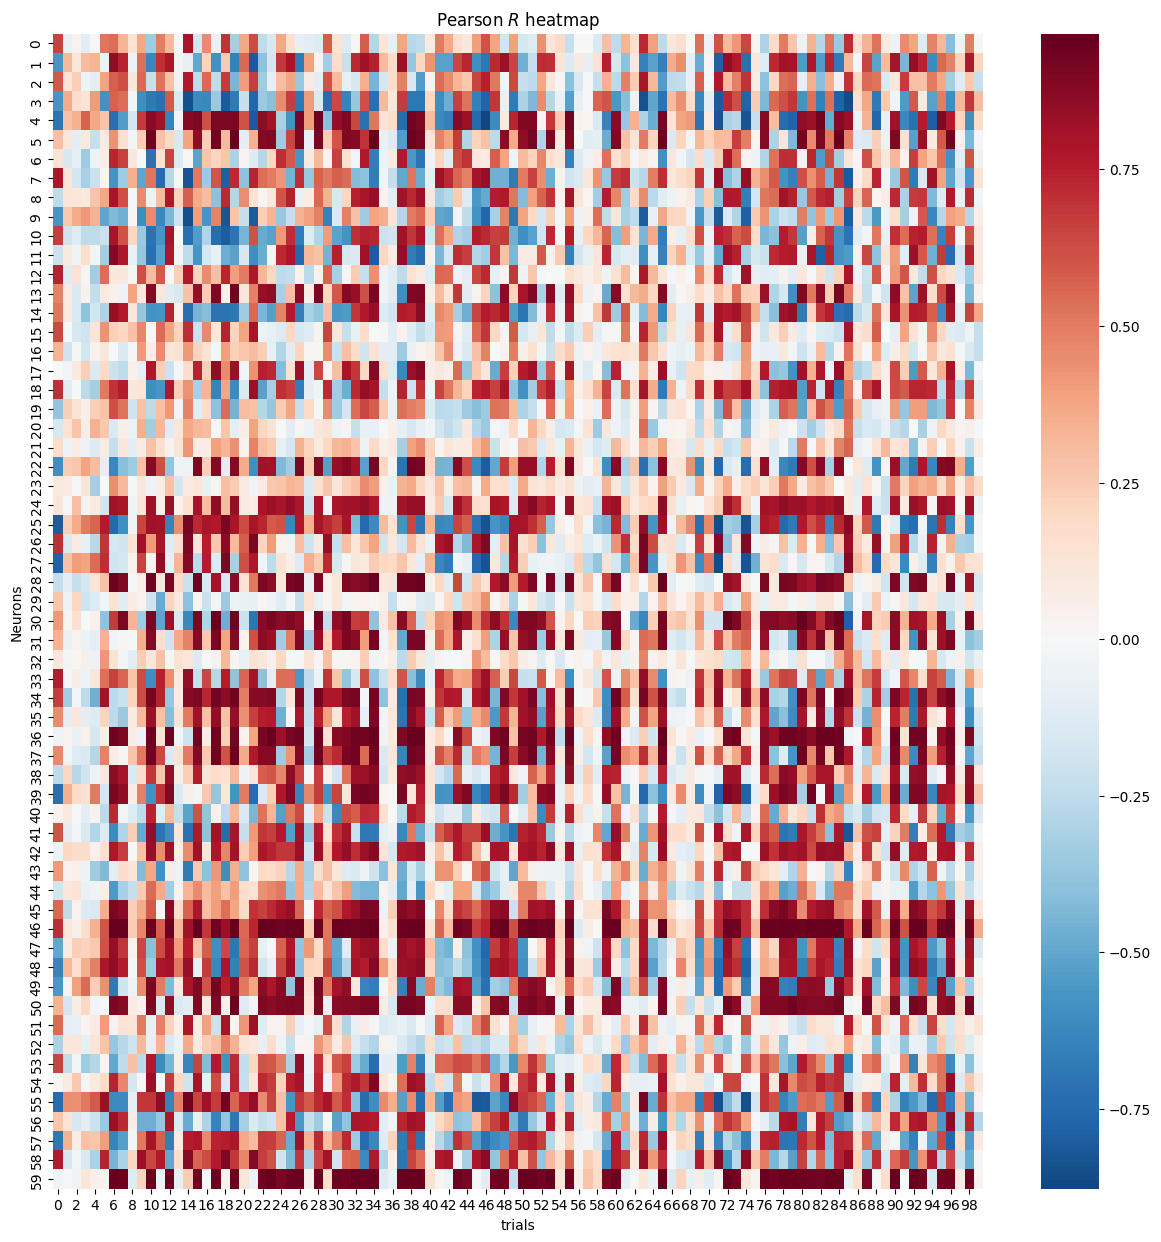

In [15]:
plt.figure(figsize=(15, 15))
# r2_arr[r2_arr < -1] = -1
sns.heatmap(pearson_r[:, :], annot=False, cmap='RdBu_r', center=0, cbar=True)
# x_ticks = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90]
# x_labels = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90]
# plt.xticks(x_ticks, x_labels)
plt.ylabel('Neurons')
plt.xlabel('trials')
plt.title(f'Pearson $R$ heatmap')
# plt.savefig('rank_scaling_pearson_r.png')

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Example data
x = np.linspace(0, 10, 100)  # X values (more points for a smoother line)
y = np.sin(x)  # Y values (e.g., a sine function)
y_err = 0.2  # Error for Y values

# Create the plot with error bars
plt.plot(x, y, '-o', label='Data with error bars')  # Line plot

# Adding shaded region to represent the error
plt.fill_between(x, y - y_err, y + y_err, color='gray', alpha=0.2, label='Error range')

# Customize the plot
plt.title("Line Plot with Shaded Error Bars")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.legend()

# Show the plot
plt.show()


In [19]:
z_traj = model.rnn.inv_observation(X_pred, grad=False)

In [68]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [ ]:
z_traj.shape

In [ ]:
%matplotlib notebook
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(z_traj[0, 0, :20], z_traj[0, 1, :20], z_traj[0, 2, :20])
ax.scatter(z_traj[0, 0, 0], z_traj[0, 1, 0], z_traj[0, 2, 0], s=10, c='r')
plt.show()

In [74]:
U, V = row_factors.clone(), column_factors.clone()
W = U @ V.T 
U, s, V =  torch.linalg.svd(W, full_matrices=False)
k = 3
U, s, V = U[:, :k], s[:k], V[:k, :]
V = s.unsqueeze(-1) * V

In [75]:
z_act = torch.einsum("zN,BNT->BzT", V, x)

In [55]:
x = x.permute(0, 2, 1)

In [ ]:
%matplotlib notebook
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(z_act[1, 0, :], z_act[1, 1, :], z_act[1, 2, :])
ax.scatter(z_act[1, 0, 0], z_act[1, 1, 0], z_act[1, 2, 0], s=10, c='r')
ax.set_xlabel('X Label')
ax.set_ylabel('Y Label')
ax.set_zlabel('Z Label')
plt.show()

In [ ]:
# %matplotlib notebook
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(z_act[1, 0, :], z_act[1, 1, :], z_act[1, 2, :])
ax.scatter(z_act[1, 0, 0], z_act[1, 1, 0], z_act[1, 2, 0], s=10, c='r')
ax.set_xlabel('X Label')
ax.set_ylabel('Y Label')
ax.set_zlabel('Z Label')
plt.show()